# Notebook outputs

This page exercises **notebook cell output rendering** — the area changed by the
`@myst-theme` v1.0.0 output-node AST change. Outputs are baked in (no execution).

In [1]:
print("hello from a stream output")

hello from a stream output


In [2]:
summary  # a plain-text execute_result

       value
count   3.0
mean    2.0
std     1.0

In [3]:
raise ValueError("a deliberate error to render the traceback")

ValueError: a deliberate error to render the traceback

In [4]:
import warnings
warnings.warn('a deliberate warning on stderr')
print('and a normal line on stdout, left visible')

W0910 10:15:26.780179 cuda_executor.cc:1802] GPU interconnect information not available


and a normal line on stdout, left visible


## Long cells

Code cells whose tags collapse a long input (`collapse-N`) or long outputs (`collapse-output-N`) behind an Expand / Collapse bar. Each case below is found by its code.

In [5]:
class LongModel:
    """A Solow growth model, long enough to collapse."""

    def __init__(self, s=0.3, alpha=0.4, delta=0.1, n=0.02, z=1.0):
        self.s = s          # savings rate
        self.alpha = alpha  # capital share
        self.delta = delta  # depreciation
        self.n = n          # population growth
        self.z = z          # productivity

    def production(self, k):
        return self.z * k ** self.alpha

    def update(self, k):
        s, delta, n = self.s, self.delta, self.n
        return (s * self.production(k) + (1 - delta) * k) / (1 + n)

    def steady_state(self):
        s, alpha, delta, n, z = self.s, self.alpha, self.delta, self.n, self.z
        return (s * z / (delta + n)) ** (1 / (1 - alpha))

    def simulate(self, k0, periods):
        path = [k0]
        for _ in range(periods - 1):
            path.append(self.update(path[-1]))
        return path

    def output_path(self, k0, periods):
        return [self.production(k) for k in self.simulate(k0, periods)]

    def consumption_path(self, k0, periods):
        return [(1 - self.s) * y for y in self.output_path(k0, periods)]

    def distance_to_steady_state(self, k0, periods):
        k_star = self.steady_state()
        return [abs(k - k_star) for k in self.simulate(k0, periods)]

    def periods_to_converge(self, k0, tol=1e-6, max_periods=10_000):
        k_star = self.steady_state()
        k = k0
        for t in range(max_periods):
            if abs(k - k_star) < tol:
                return t
            k = self.update(k)
        raise RuntimeError("did not converge")

    def __repr__(self):
        return f"LongModel(s={self.s}, alpha={self.alpha}, delta={self.delta})"

In [6]:
for i in range(60):
    print(f"iteration {i:2d}: error {0.5 ** i:.3e}")

iteration  0: error 1.000e+00
iteration  1: error 5.000e-01
iteration  2: error 2.500e-01
iteration  3: error 1.250e-01
iteration  4: error 6.250e-02
iteration  5: error 3.125e-02
iteration  6: error 1.562e-02
iteration  7: error 7.812e-03
iteration  8: error 3.906e-03
iteration  9: error 1.953e-03
iteration 10: error 9.766e-04
iteration 11: error 4.883e-04
iteration 12: error 2.441e-04
iteration 13: error 1.221e-04
iteration 14: error 6.104e-05
iteration 15: error 3.052e-05
iteration 16: error 1.526e-05
iteration 17: error 7.629e-06
iteration 18: error 3.815e-06
iteration 19: error 1.907e-06
iteration 20: error 9.537e-07
iteration 21: error 4.768e-07
iteration 22: error 2.384e-07
iteration 23: error 1.192e-07
iteration 24: error 5.960e-08
iteration 25: error 2.980e-08
iteration 26: error 1.490e-08
iteration 27: error 7.451e-09
iteration 28: error 3.725e-09
iteration 29: error 1.863e-09
iteration 30: error 9.313e-10
iteration 31: error 4.657e-10
iteration 32: error 2.328e-10
iteration 

In [7]:
total = sum(range(10))
total

45

In [8]:
print("a short output")

a short output


In [9]:
no_output = True

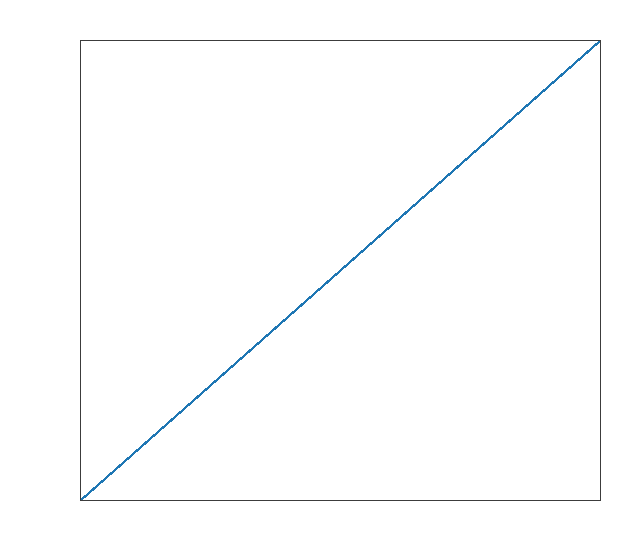

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.plot(x, x)
plt.show()